<a href="https://colab.research.google.com/github/KlimTimiryazev/ML-test-5.4.26/blob/main/%D0%9A%D0%A03_%D1%81%D0%BA%D0%B5%D0%BB%D0%B5%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════╗
# ║           КР-3: Диагностика моделей МО       ║
# ║   Файл: Фамилия_группа.ipynb                 ║
# ╚══════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
from sklearn.datasets import fetch_openml

# Предобработка
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, learning_curve,
                                     validation_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

# Метрики — классификация
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

# Метрики — регрессия
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, mean_absolute_percentage_error)

# Модели — классификация
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Модели — регрессия
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

print("✅ Библиотеки загружены.")


✅ Библиотеки загружены.


## Задание 1 (1 балл) — Загрузка датасета

In [2]:
# ┌─────────────────────────────────────────┐
# │  ⬇ ВСТАВЬ НАЗВАНИЕ ДАТАСЕТА СЮДА       │
DATASET_NAME = 'iris'   # <-- меняй только это
# └─────────────────────────────────────────┘

data = fetch_openml(name=DATASET_NAME, version=1, as_frame=True, parser='auto')

print("=" * 60)
print(f"Датасет: {DATASET_NAME}")
print("=" * 60)
print()
# Текстовое описание датасета (из поля DESCR)
if data.DESCR:
    print(data.DESCR[:1500])
else:
    print("Описание отсутствует.")


Датасет: iris

**Author**: R.A. Fisher  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Iris) - 1936 - Donated by Michael Marshall  
**Please cite**:   

**Iris Plants Database**  
This is perhaps the best known database to be found in the pattern recognition literature.  Fisher's paper is a classic in the field and is referenced frequently to this day.  (See Duda & Hart, for example.)  The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.  One class is     linearly separable from the other 2; the latter are NOT linearly separable from each other.

Predicted attribute: class of iris plant.  
This is an exceedingly simple domain.  
 
### Attribute Information:
    1. sepal length in cm
    2. sepal width in cm
    3. petal length in cm
    4. petal width in cm
    5. class: 
       -- Iris Setosa
       -- Iris Versicolour
       -- Iris Virginica

Downloaded from openml.org.


**Вывод (заполнить):**

- **Бизнес-задача:** *например, предсказать вероятность заболевания по медицинским показателям*
- **Задача МО:** *классификация / регрессия — почему?*
- **Целевая переменная:** *название столбца, что означает*


## Задание 2 (1 балл) — Предварительный анализ датасета

Размерность X: (150, 4)
Тип target: category



,sepallength,sepalwidth,petallength,petalwidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



📊 Описательная статистика:


,sepallength,sepalwidth,petallength,petalwidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



📋 Типы данных:
sepallength    float64
sepalwidth     float64
petallength    float64
petalwidth     float64
dtype: object

🎯 Распределение целевой переменной:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Минимальный класс: 50 | Максимальный: 50
Соотношение: 1.00  (< 0.5 — есть дисбаланс)


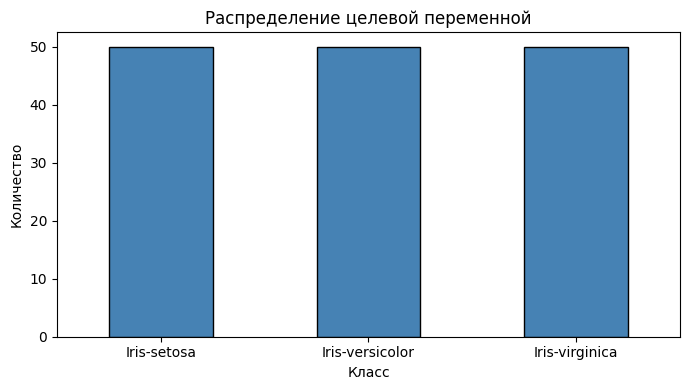

In [3]:
# Разделяем на признаки и целевую переменную
X_raw = data.data.copy()
y_raw = data.target.copy()

print(f"Размерность X: {X_raw.shape}")
print(f"Тип target: {y_raw.dtype}")
print()
display(X_raw.head(5))
print()

# --- Основная статистика ---
print("📊 Описательная статистика:")
display(X_raw.describe())

# --- Типы столбцов ---
print("\n📋 Типы данных:")
print(X_raw.dtypes)

# --- Дисбаланс целевого признака ---
print("\n🎯 Распределение целевой переменной:")
vc = y_raw.value_counts()
print(vc)
print(f"\nМинимальный класс: {vc.min()} | Максимальный: {vc.max()}")
print(f"Соотношение: {vc.min()/vc.max():.2f}  (< 0.5 — есть дисбаланс)")

plt.figure(figsize=(7, 4))
vc.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Распределение целевой переменной")
plt.xlabel("Класс"); plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


**Вывод (заполнить):**

- Датасет содержит **N** объектов и **M** признаков.
- Целевая переменная **сбалансирована / несбалансирована** (соотношение ≈ ...).
- *Если дисбаланс — упомяни, как это влияет на выбор метрики.*


## Задание 3 (1 балл) — Подготовка данных к моделированию

In [4]:
X = X_raw.copy()
y = y_raw.copy()

# ── 1. Проверка пропусков ──────────────────────────────────────────
missing = X.isnull().sum()
print("❓ Пропуски по столбцам:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет ✅")

# Заполнение пропусков (раскомментируй если нужно)
# num_cols = X.select_dtypes(include='number').columns
# cat_cols = X.select_dtypes(exclude='number').columns
# imputer_num = SimpleImputer(strategy='median')
# imputer_cat = SimpleImputer(strategy='most_frequent')
# X[num_cols] = imputer_num.fit_transform(X[num_cols])
# X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])

# ── 2. Кодирование категориальных признаков ───────────────────────
cat_cols = X.select_dtypes(exclude='number').columns
if len(cat_cols) > 0:
    print(f"\n🔤 Категориальные столбцы: {list(cat_cols)}")
    # Один из вариантов — Label Encoding (подходит для деревьев)
    for col in cat_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    print("Закодированы через LabelEncoder.")
    # Альтернатива — One-Hot:
    # X = pd.get_dummies(X, columns=cat_cols)
else:
    print("\n✅ Все признаки уже числовые.")

# ── 3. Кодирование целевой переменной ─────────────────────────────
if y.dtype == 'object' or str(y.dtype) == 'category':
    print(f"\n🎯 Целевая переменная — категориальная, кодируем...")
    le_target = LabelEncoder()
    y = pd.Series(le_target.fit_transform(y.astype(str)), name='target')
    print(f"Классы: {le_target.classes_}")
else:
    y = y.astype(float)

# ── 4. Определение типа задачи ────────────────────────────────────
n_unique = y.nunique()
TASK_TYPE = 'classification' if n_unique <= 20 else 'regression'
print(f"\n🧩 Тип задачи определён автоматически: {TASK_TYPE}")
print(f"   (уникальных значений target: {n_unique})")
# Если не угадало — поменяй вручную:
# TASK_TYPE = 'classification'
# TASK_TYPE = 'regression'

print("\n✅ Данные готовы к моделированию.")
print(f"   X shape: {X.shape}, y shape: {y.shape}")


❓ Пропуски по столбцам:
Пропусков нет ✅

✅ Все признаки уже числовые.

🎯 Целевая переменная — категориальная, кодируем...
Классы: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

🧩 Тип задачи определён автоматически: classification
   (уникальных значений target: 3)

✅ Данные готовы к моделированию.
   X shape: (150, 4), y shape: (150,)


**Вывод (заполнить):**

- Пропущенных значений: **0 / N**.
- Категориальных признаков: **0 / N** — *что сделали*.
- Данные пригодны для моделирования.


### Разбивка на train/test + нормализация

In [5]:
# Разбивка
if TASK_TYPE == 'classification':
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

# Нормализация (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Scaler mean (первые 3): {scaler.mean_[:3].round(3)}")


Train: (120, 4), Test: (30, 4)
Scaler mean (первые 3): [5.842 3.044 3.771]


## Задание 4 (1 балл) — Линейная модель + метрика score()

In [6]:
# Линейная модель
if TASK_TYPE == 'classification':
    linear_model = LogisticRegression(max_iter=1000, random_state=42)
    metric_name = "Accuracy (доля правильных ответов)"
else:
    linear_model = LinearRegression()
    metric_name = "R² (коэффициент детерминации)"

linear_model.fit(X_train_scaled, y_train)

train_score = linear_model.score(X_train_scaled, y_train)
test_score  = linear_model.score(X_test_scaled,  y_test)

print(f"Модель: {linear_model.__class__.__name__}")
print(f"Метрика score(): {metric_name}")
print()
print(f"  Train score: {train_score:.4f}")
print(f"  Test  score: {test_score:.4f}")


Модель: LogisticRegression
Метрика score(): Accuracy (доля правильных ответов)

  Train score: 0.9583
  Test  score: 0.9333


**Вывод (заполнить):**

Метод `score()` для LogisticRegression считает **Accuracy** — долю правильно классифицированных объектов.  
Для LinearRegression — **R²** — долю объяснённой дисперсии (1 = идеально, 0 = константная модель).

Результат на тесте: **...**


## Задание 5 (1 балл) — 3 дополнительные метрики

In [7]:
y_pred_linear = linear_model.predict(X_test_scaled)

if TASK_TYPE == 'classification':
    avg = 'binary' if y.nunique() == 2 else 'weighted'

    p  = precision_score(y_test, y_pred_linear, average=avg, zero_division=0)
    r  = recall_score   (y_test, y_pred_linear, average=avg, zero_division=0)
    f1 = f1_score       (y_test, y_pred_linear, average=avg, zero_division=0)

    print("Метрики классификации (линейная модель):")
    print(f"  Precision : {p:.4f}  — из всех предсказанных '1' сколько верных")
    print(f"  Recall    : {r:.4f}  — из всех реальных '1' сколько нашли")
    print(f"  F1 Score  : {f1:.4f} — гармоническое среднее Precision и Recall")
    print()
    print(classification_report(y_test, y_pred_linear, zero_division=0))

else:
    mae  = mean_absolute_error(y_test, y_pred_linear)
    mse  = mean_squared_error (y_test, y_pred_linear)
    rmse = np.sqrt(mse)

    print("Метрики регрессии (линейная модель):")
    print(f"  MAE  : {mae:.4f}  — средняя абсолютная ошибка (в единицах target)")
    print(f"  MSE  : {mse:.4f}  — среднеквадратичная ошибка (штрафует выбросы)")
    print(f"  RMSE : {rmse:.4f} — корень из MSE (интерпретируется в единицах target)")


Метрики классификации (линейная модель):
  Precision : 0.9333  — из всех предсказанных '1' сколько верных
  Recall    : 0.9333  — из всех реальных '1' сколько нашли
  F1 Score  : 0.9333 — гармоническое среднее Precision и Recall

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



**Вывод (заполнить):**

- Precision = ... — *что означает для данной задачи*
- Recall = ... — *что означает*
- F1 = ... — *итоговая оценка*


## Задание 6 (1 балл) — ROC-кривые / Анализ остатков

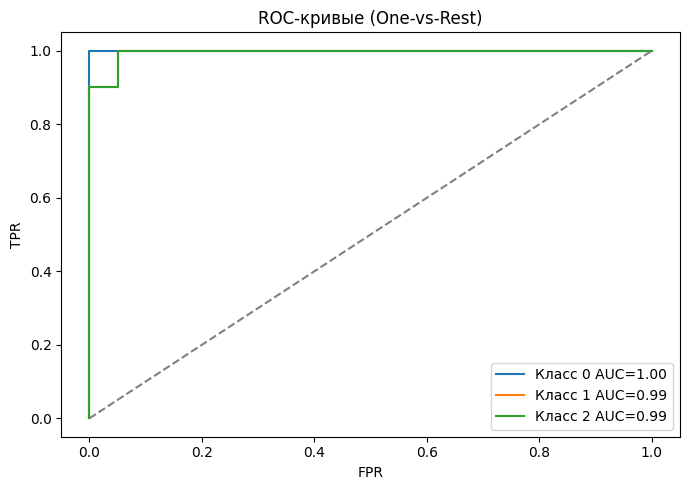

Macro ROC-AUC: 0.9967


In [8]:
if TASK_TYPE == 'classification':
    n_classes = y.nunique()

    if n_classes == 2:
        # ── Бинарная классификация ─────────────────────────────────
        y_score = linear_model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}', lw=2)
        plt.plot([0,1],[0,1],'--', color='grey')
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC-кривая")
        plt.legend(); plt.tight_layout(); plt.show()

        # Оптимальный порог (максимум Youden's J)
        j_scores = tpr - fpr
        opt_idx  = np.argmax(j_scores)
        opt_threshold = thresholds[opt_idx]
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"Оптимальный порог (Youden): {opt_threshold:.4f}")
        print(f"  При этом пороге: TPR={tpr[opt_idx]:.3f}, FPR={fpr[opt_idx]:.3f}")

    else:
        # ── Многоклассовая — One-vs-Rest ───────────────────────────
        from sklearn.preprocessing import label_binarize
        classes = np.unique(y)
        y_bin   = label_binarize(y_test, classes=classes)
        y_score = linear_model.predict_proba(X_test_scaled)

        plt.figure(figsize=(7, 5))
        for i, cls in enumerate(classes):
            fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_score[:, i])
            roc_i = auc(fpr_i, tpr_i)
            plt.plot(fpr_i, tpr_i, label=f'Класс {cls} AUC={roc_i:.2f}')
        plt.plot([0,1],[0,1],'--', color='grey')
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC-кривые (One-vs-Rest)")
        plt.legend(); plt.tight_layout(); plt.show()

        macro_auc = roc_auc_score(y_bin, y_score, multi_class='ovr', average='macro')
        print(f"Macro ROC-AUC: {macro_auc:.4f}")

else:
    # ── Регрессия: теоретические vs эмпирические ──────────────────
    residuals = y_test.values - y_pred_linear

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter: предсказанное vs реальное
    axes[0].scatter(y_test, y_pred_linear, alpha=0.5, color='steelblue')
    lims = [min(y_test.min(), y_pred_linear.min()),
            max(y_test.max(), y_pred_linear.max())]
    axes[0].plot(lims, lims, 'r--', lw=2)
    axes[0].set_xlabel("Реальные значения")
    axes[0].set_ylabel("Предсказания")
    axes[0].set_title("Предсказания vs Реальные")

    # Остатки
    axes[1].scatter(y_pred_linear, residuals, alpha=0.5, color='coral')
    axes[1].axhline(0, color='black', lw=2, ls='--')
    axes[1].set_xlabel("Предсказания")
    axes[1].set_ylabel("Остатки")
    axes[1].set_title("Остатки модели")

    plt.tight_layout(); plt.show()

    print(f"Среднее остатков: {residuals.mean():.4f}  (≈0 → нет систематической ошибки)")
    print(f"Std остатков: {residuals.std():.4f}")


**Вывод (заполнить):**

- ROC-AUC = ... — *что означает*
- Оптимальный порог: ... — *как влияет на Precision/Recall*

*(для регрессии)*: Остатки распределены случайно / есть систематическая компонента (перекос в сторону ...).


## Задание 7 (1 балл) — PR-кривые / Нормализация

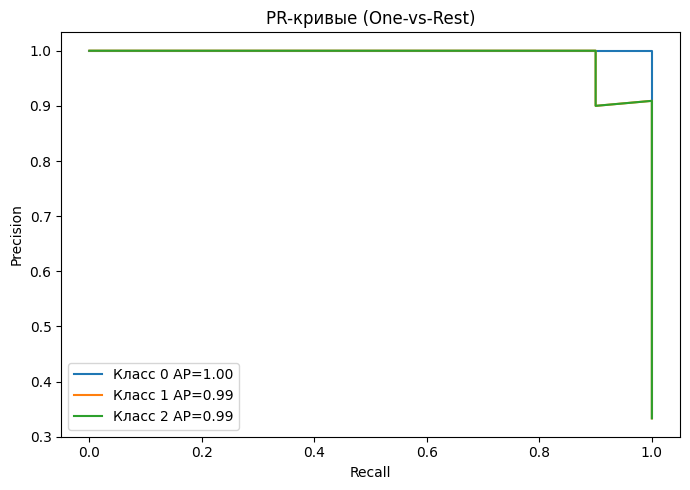

In [9]:
if TASK_TYPE == 'classification':
    n_classes = y.nunique()

    if n_classes == 2:
        y_score = linear_model.predict_proba(X_test_scaled)[:, 1]
        precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_score)
        pr_auc = average_precision_score(y_test, y_score)

        plt.figure(figsize=(6, 5))
        plt.plot(recall_arr, precision_arr, label=f'PR AUC = {pr_auc:.3f}', lw=2)
        plt.xlabel("Recall"); plt.ylabel("Precision")
        plt.title("PR-кривая"); plt.legend()
        plt.tight_layout(); plt.show()

        # Оптимальный порог (максимум F1)
        f1_scores  = 2 * precision_arr[:-1] * recall_arr[:-1] / (
                     precision_arr[:-1] + recall_arr[:-1] + 1e-8)
        opt_idx_pr = np.argmax(f1_scores)
        opt_thr_pr = thresholds_pr[opt_idx_pr]
        print(f"PR-AUC: {pr_auc:.4f}")
        print(f"Оптимальный порог (макс. F1): {opt_thr_pr:.4f}")
        print(f"  Precision={precision_arr[opt_idx_pr]:.3f}, Recall={recall_arr[opt_idx_pr]:.3f}")

    else:
        from sklearn.preprocessing import label_binarize
        classes = np.unique(y)
        y_bin   = label_binarize(y_test, classes=classes)
        y_score = linear_model.predict_proba(X_test_scaled)

        plt.figure(figsize=(7, 5))
        for i, cls in enumerate(classes):
            p_i, r_i, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
            ap_i = average_precision_score(y_bin[:, i], y_score[:, i])
            plt.plot(r_i, p_i, label=f'Класс {cls} AP={ap_i:.2f}')
        plt.xlabel("Recall"); plt.ylabel("Precision")
        plt.title("PR-кривые (One-vs-Rest)"); plt.legend()
        plt.tight_layout(); plt.show()

else:
    # ── Регрессия с нормализацией ────────────────────────────────
    scaler_mm = MinMaxScaler()
    X_train_mm = scaler_mm.fit_transform(X_train)
    X_test_mm  = scaler_mm.transform(X_test)

    model_norm = LinearRegression()
    model_norm.fit(X_train_mm, y_train)
    y_pred_norm = model_norm.predict(X_test_mm)

    r2_orig = r2_score(y_test, y_pred_linear)
    r2_norm = r2_score(y_test, y_pred_norm)
    mae_orig = mean_absolute_error(y_test, y_pred_linear)
    mae_norm = mean_absolute_error(y_test, y_pred_norm)

    print("Сравнение до/после нормализации (MinMaxScaler):")
    print(f"  R²  : без норм. = {r2_orig:.4f}  |  с норм. = {r2_norm:.4f}")
    print(f"  MAE : без норм. = {mae_orig:.4f}  |  с норм. = {mae_norm:.4f}")
    print()
    print("Вывод: для LinearRegression нормализация НЕ влияет на R²,")
    print("но важна для моделей на основе расстояний (KNN, SVM).")


**Вывод (заполнить):**

- PR-AUC = ... — *чем отличается от ROC-AUC, когда важнее*
- Оптимальный порог по F1 = ...

*(для регрессии)*: Нормализация для LinearRegression практически не влияет на метрики,
т.к. линейная модель инвариантна к масштабу признаков.


## Задание 8 (1 балл) — Кросс-валидация

In [10]:
# Вторая модель для кросс-валидации
if TASK_TYPE == 'classification':
    model_cv = RandomForestClassifier(n_estimators=50, random_state=42)
    scoring  = 'accuracy'
    # Для классификации — Stratified KFold (сохраняет баланс классов в фолдах)
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_name = "StratifiedKFold(5)"
    reason  = "Используем StratifiedKFold, т.к. задача классификации — нужно сохранить пропорции классов в каждом фолде."
else:
    model_cv = RandomForestRegressor(n_estimators=50, random_state=42)
    scoring  = 'r2'
    # Для регрессии — обычный KFold
    cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_name = "KFold(5)"
    reason  = "Используем KFold, т.к. задача регрессии — нет классов, просто случайное перемешивание."

print(f"Тип кросс-валидации: {cv_name}")
print(f"Обоснование: {reason}")
print()

cv_scores = cross_val_score(model_cv, X_train_scaled, y_train,
                             cv=cv_strategy, scoring=scoring)

print(f"CV scores ({scoring}): {cv_scores.round(4)}")
print(f"Среднее: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Дополнительно: обучаем на всём train и смотрим тест
model_cv.fit(X_train_scaled, y_train)
test_score_cv = model_cv.score(X_test_scaled, y_test)
print(f"Score на тесте: {test_score_cv:.4f}")


Тип кросс-валидации: StratifiedKFold(5)
Обоснование: Используем StratifiedKFold, т.к. задача классификации — нужно сохранить пропорции классов в каждом фолде.

CV scores (accuracy): [0.9583 1.     0.9583 0.9583 0.9167]
Среднее: 0.9583 ± 0.0264
Score на тесте: 0.9000


**Вывод (заполнить):**

Выбран **StratifiedKFold / KFold** с 5 фолдами, потому что ...

Средний CV score = ... ± ... — *что говорит об устойчивости модели*.


## Задание 9 (2 балла) — Кривые обучения

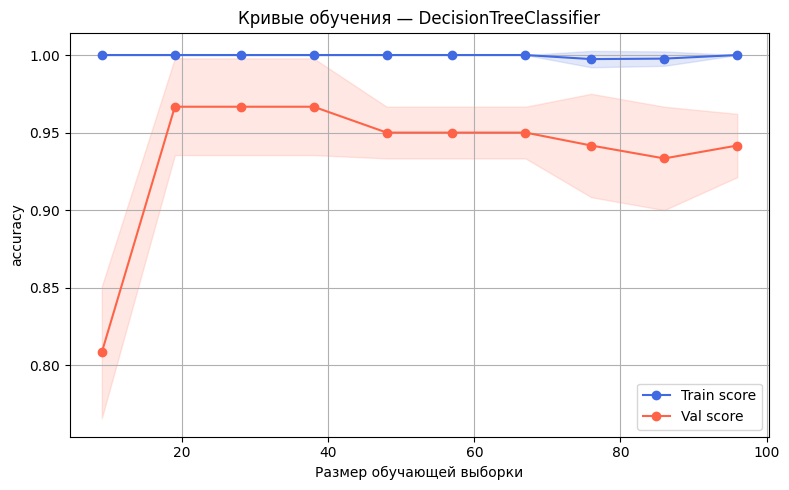

Train score (финал): 1.0000
Val   score (финал): 0.9417
Разрыв: 0.0583
✅ Модель обучается нормально.


In [11]:
# Модель для диагностики
if TASK_TYPE == 'classification':
    model_lc = DecisionTreeClassifier(max_depth=5, random_state=42)
    scoring_lc = 'accuracy'
else:
    model_lc = DecisionTreeRegressor(max_depth=5, random_state=42)
    scoring_lc = 'r2'

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X_train_scaled, y_train,
    cv=5, scoring=scoring_lc,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Train score')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 'o-', color='tomato', label='Val score')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='tomato')
plt.xlabel("Размер обучающей выборки")
plt.ylabel(scoring_lc)
plt.title(f"Кривые обучения — {model_lc.__class__.__name__}")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

final_train = train_mean[-1]
final_val   = val_mean[-1]
gap = final_train - final_val

print(f"Train score (финал): {final_train:.4f}")
print(f"Val   score (финал): {final_val:.4f}")
print(f"Разрыв: {gap:.4f}")
if gap > 0.1:
    print("⚠️  Разрыв > 0.1 — возможно ПЕРЕОБУЧЕНИЕ (high variance)")
elif final_val < 0.7:
    print("⚠️  Val score низкий — возможно НЕДООБУЧЕНИЕ (high bias)")
else:
    print("✅ Модель обучается нормально.")


**Вывод (заполнить):**

- Train score = ..., Val score = ..., разрыв = ...
- Кривые **сходятся / расходятся** — это говорит о **переобучении / недообучении / норме**.
- *Что можно сделать для улучшения: уменьшить max_depth / добавить данных / регуляризацию*


## Задание 10 (2 балла) — Влияние гиперпараметра на качество модели

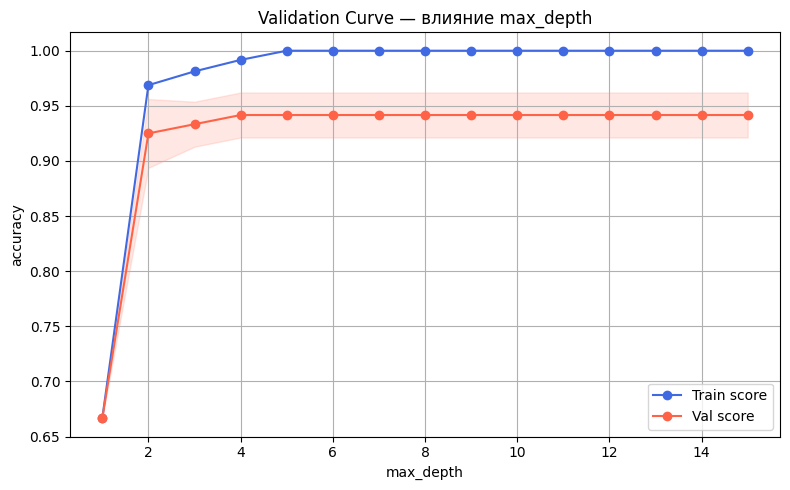

Лучшее значение max_depth: 4
  Val score при лучшем значении: 0.9417

Интерпретация:
  Малый max_depth → недообучение (модель слишком простая)
  Большой max_depth → переобучение (запоминает шум)
  Оптимум ≈ 4


In [12]:
# Исследуем влияние max_depth для Decision Tree
if TASK_TYPE == 'classification':
    model_vc  = DecisionTreeClassifier(random_state=42)
    param_range = np.arange(1, 16)
    scoring_vc  = 'accuracy'
    param_name  = 'max_depth'
else:
    model_vc  = DecisionTreeRegressor(random_state=42)
    param_range = np.arange(1, 16)
    scoring_vc  = 'r2'
    param_name  = 'max_depth'

train_vc, val_vc = validation_curve(
    model_vc, X_train_scaled, y_train,
    param_name=param_name, param_range=param_range,
    cv=5, scoring=scoring_vc, n_jobs=-1
)

train_vc_mean = train_vc.mean(axis=1)
val_vc_mean   = val_vc.mean(axis=1)
val_vc_std    = val_vc.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_vc_mean, 'o-', color='royalblue', label='Train score')
plt.plot(param_range, val_vc_mean,   'o-', color='tomato',    label='Val score')
plt.fill_between(param_range, val_vc_mean-val_vc_std, val_vc_mean+val_vc_std, alpha=0.15, color='tomato')
plt.xlabel(param_name); plt.ylabel(scoring_vc)
plt.title(f"Validation Curve — влияние {param_name}")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

best_depth = param_range[np.argmax(val_vc_mean)]
print(f"Лучшее значение {param_name}: {best_depth}")
print(f"  Val score при лучшем значении: {val_vc_mean[best_depth-1]:.4f}")
print()
print("Интерпретация:")
print("  Малый max_depth → недообучение (модель слишком простая)")
print("  Большой max_depth → переобучение (запоминает шум)")
print(f"  Оптимум ≈ {best_depth}")


**Вывод (заполнить):**

- При `max_depth` < ... модель **недообучается**: Train и Val score оба низкие.
- При `max_depth` > ... — **переобучение**: Train растёт, Val падает.
- Оптимальное значение: `max_depth` = ...
